In [94]:
import numpy as np 
import pandas as pd

In [95]:
df = pd.read_csv('spam.csv', encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [96]:
df.shape

(5572, 5)

In [97]:
# 1. Data Cleaning 
# 2. EDA
#.3. Text Preprocessing 
# 4. Model Build 
# 5. Evaluation 
# 6. Improvement 
# 7. Website 
# 8. Deploy 

## DATA CLEANING

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [99]:
# droping last three columns 
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'] , inplace= True)

In [100]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [101]:
# renamimng cols
df.rename(columns={'v1':'target', 'v2':'text'}, inplace= True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [102]:
# target me numerical values chiye  ham ko 0 or spam ko 1 
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


In [103]:
df['target']=encoder.fit_transform(df['target'])

In [104]:
df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [105]:
df.isnull().sum() # missing values

target    0
text      0
dtype: int64

In [106]:
df.duplicated().sum()# check for duplicate values 

np.int64(403)

In [107]:
df = df.drop_duplicates(keep='first')

In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
df.shape

(5169, 2)

## EDA

In [110]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

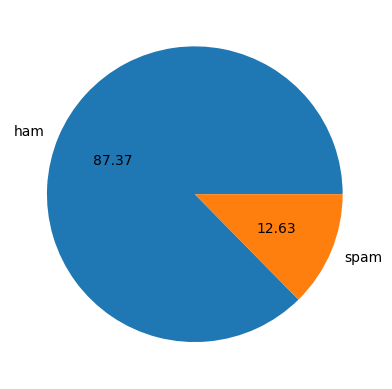

In [111]:
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels= ['ham','spam'], autopct='%0.2f')
plt.show()

## Data is imbalanced 

In [112]:
import nltk

In [113]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [114]:
df['num_charactrs']= df['text'].apply(len)

In [115]:
df.head()

,target,text,num_charactrs
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


## messages ko word me brk kiya h or unka length count liya h 

In [116]:
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [117]:
df.head()

,target,text,num_charactrs,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


## similarly sentence me brk krk count lege with sent_tokenize of nltk

In [118]:
df['num_sent']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [119]:
df.head()

,target,text,num_charactrs,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [120]:
df[['num_charactrs','num_words','num_sent']].describe()

,num_charactrs,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


## We can see here that there is a sentence or a word in which maximum 900 10 characters are used

## Analyzing ham and spam seperately 

In [121]:
df[df['target'] == 0][['num_charactrs','num_words','num_sent']].describe()

,num_charactrs,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [122]:
df[df['target'] == 1][['num_charactrs','num_words','num_sent']].describe()

,num_charactrs,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


## Here is the huge differe between the mean of the ham and spam messages

In [123]:
import seaborn as sns 

<Axes: xlabel='num_charactrs', ylabel='Count'>

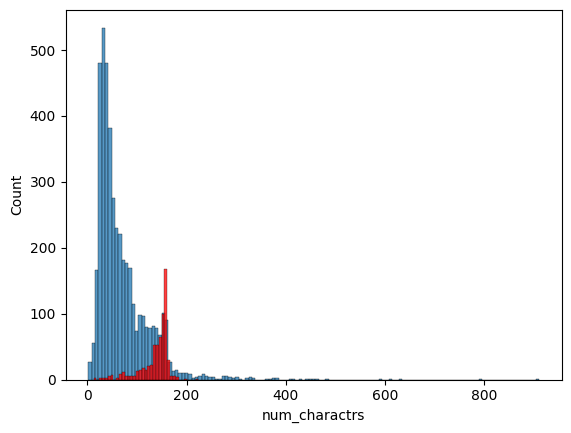

In [124]:
sns.histplot(df[df['target']== 0]['num_charactrs'])
sns.histplot(df[df['target']== 1]['num_charactrs'],color='red')

## We can analyze the same with number of words and number of sentences

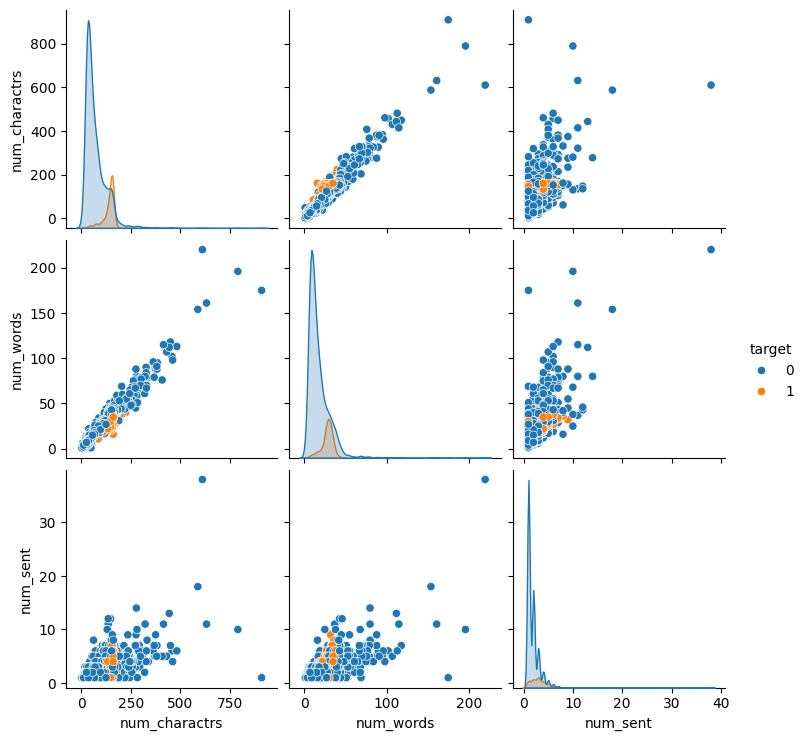

In [125]:
## columns ka apas me relation 
sns.pairplot(df, hue='target')

## outliers h data me 

<Axes: >

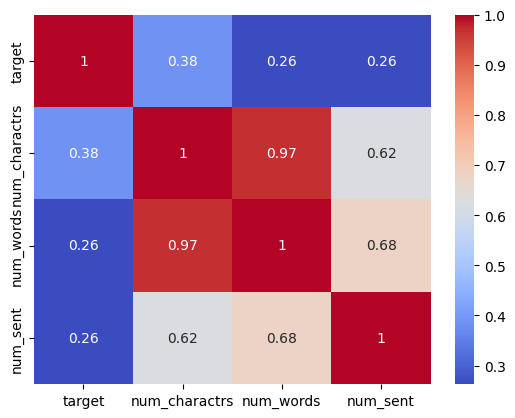

In [126]:
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True, cmap='coolwarm')

## num_charctrs aur num_words highly correlated (0.97) hain → dono ko model me rakhne se duplicate info milegi.
## 👉 So, ek hi feature rakhna better hai (usually num_charctrs since it’s more correlated with target).

num_charctrs ka correlation target se zyada (0.38) hone ka matlab:

spam messages generally lambe (zyada characters wale) hote hain.

## 3. Data Preprocessing 
1. lowercase
2. tokenization 
3. removing special characters 
4. removig stop words and punctuation 
5. stemming

In [127]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [128]:
import string 
string.punctuation


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [129]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)


    y =[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:] 
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:  
            y.append(i) 

    text = y[:] 
    y.clear()  
    for i in text:
        y.append(ps.stem(i))          

    return  " ".join(y) 

In [130]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [131]:
import nltk

transform_text('Hi how Are Nitish  why are u dancing 34$??')



'hi nitish u danc 34'

In [132]:
df['transformed_text']=df['text'].apply(transform_text)


In [133]:
df.head()

,target,text,num_charactrs,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## Word cloud key helps hum check kareena Ki kisi bhi message me like text ski frequency checker Ki EK Message My  word kidney bar Aaya Hua Its just a textual data analysis

In [134]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height= 500,min_font_size=10, background_color='white')

## ye Sare Spam Messages ko Long String me Jod rha h 

In [135]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

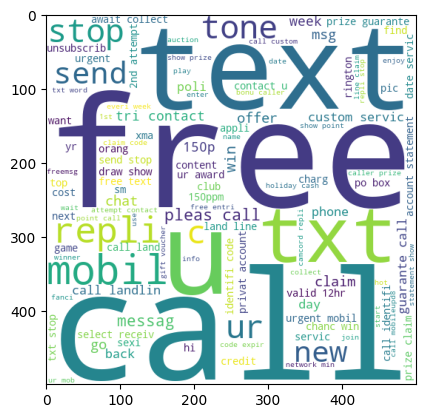

In [136]:
plt.imshow(spam_wc)

## same doing for ham messages

In [137]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

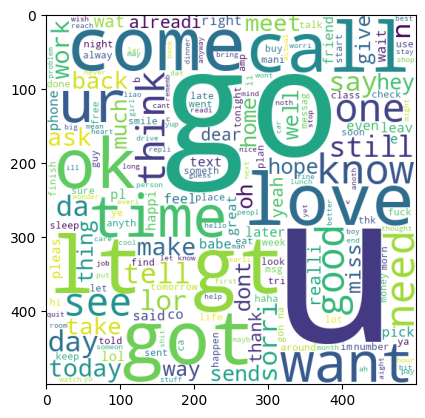

In [138]:
plt.imshow(ham_wc)

In [139]:
df.head()

,target,text,num_charactrs,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## What gonna do is to find top 30 words that are repeating in spam as well as ham messages So what we're gonna do is to extract the spam rows or the ham rows with the transformed text and converting them into the big list of strings and then applying for loop on that

In [140]:

spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [141]:
len(spam_corpus)


9939

C:\Users\HP\AppData\Local\Temp\ipykernel_8580\553152988.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= 'word', y = 'count', data = df_spam, palette='coolwarm')


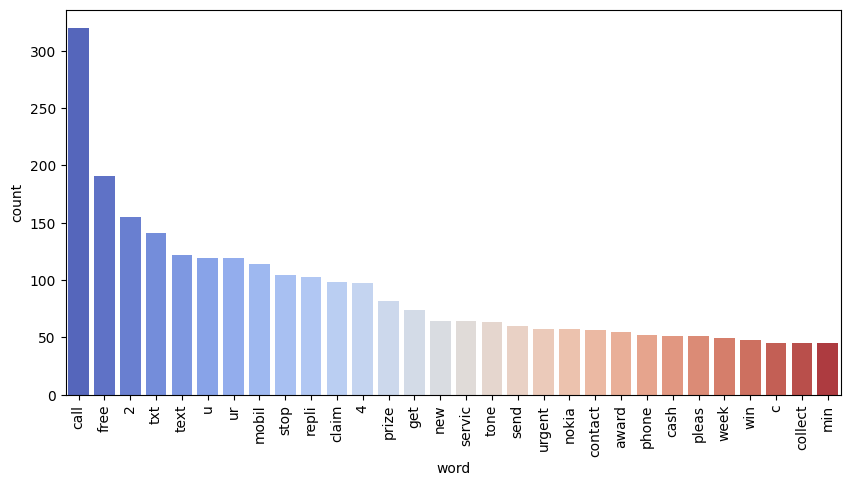

In [142]:
from collections import Counter 
## count top most 30 words 
spam_wc=Counter(spam_corpus).most_common(30)

## converting it into dataframe 
df_spam = pd.DataFrame(spam_wc, columns=['word', 'count'])

## plot bar chart 
plt.figure(figsize=(10,5))
sns.barplot(x= 'word', y = 'count', data = df_spam, palette='coolwarm')
plt.xticks(rotation=90)
plt.show()

In [143]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [144]:
len(ham_corpus)

35404

C:\Users\HP\AppData\Local\Temp\ipykernel_8580\752224431.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= 'word', y = 'count', data = df_ham, palette='coolwarm')


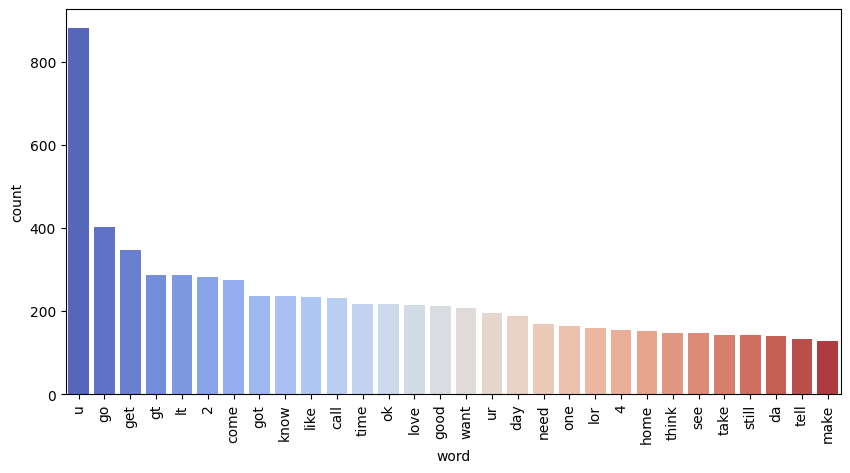

In [145]:
from collections import Counter 
## count top most 30 words 
ham_wc=Counter(ham_corpus).most_common(30)

## converting it into dataframe 
df_ham = pd.DataFrame(ham_wc, columns=['word', 'count'])

## plot bar chart 
plt.figure(figsize=(10,5))
sns.barplot(x= 'word', y = 'count', data = df_ham, palette='coolwarm')
plt.xticks(rotation=90)
plt.show()

## 4. Model building but before that will convert our input data into numerical form that is text vectorization because Navey bayes work best on textual data but that takes numeric as input so we have to do text vectorization

## Text vectorization 
## using bag of words
Bag of words method may hum frequent words ka Ek colom banalette or her spam message may check kartiki who frequent word kitni baraya or woh vector banjatai

In [146]:
df.head()

,target,text,num_charactrs,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## Just for testing we're trying TFIDF for vectorization instead of using count vectoriser

In [147]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
##cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000) ## max_feature hidden paramtere ise improvent k liye set kiya h ki hm sare ko na lker kuch top most words ko vectorize krna chte h 

In [148]:
##X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

## we are trying ki scaling se kuch model ka performance improve ho jye after  improvement  standard sacler isliye ni use kiya kyunki wo kuch negative values bhi deta h jo ki navey ayes accpt ni krega 

In [149]:
##from sklearn.preprocessing import MinMaxScaler
## scaler = MinMaxScaler()
## X = scaler.fit_transform(X)

## Scaling se koi khaas frk ni pda o hm use include ni krnege but we ae tyring by adding num_chars column in X to see diff 

In [150]:
# appending the num_character col to X
# X = np.hstack((X,df['num_charactrs'].values.reshape(-1,1)))

In [151]:
##mnb.fit(X_train, y_train)

In [152]:
X.shape

(5169, 3000)

In [153]:
y = df['target'].values

In [154]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [155]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [156]:
mnb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [157]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))



0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [158]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


## Here MNB is good working on TF IDF vectorization because precision score has improved a lot it's reducing first positive An accuracy score is also good  Either we can go with the multinomial or Bernoulli's  since precision score matters more here that's why we are choosing multinomial which has improved precision spots a lot

In [159]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))


0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


## If we see her accuracy score and precision score is best in BNB that is Bernoulli's Navy buys because precision matters more because the data is imbalanced here

## So finally we are choosing multinomial Navebiz TF IDF vectorization

## Now we are comparing different algorithms or different machine learning models with the multinomial name bias to see which performs best

In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import pkg_resources

print(pkg_resources.get_distribution("pandas").version)


2.3.2


In [161]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc  = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)


In [162]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    'AdaBoost' : abc,
    'BgC' : bc,
    'ETC' : etc,
    'GBDT' : gbdt,
    'xgb' : xgb
}



## Here is a simple dictionary which includes values of all the algorithms and a function named as train classifier in which we have passed classifier and training and testing data which is training the model and making predictions on test data and calculating accuracy and precision

In [163]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)                      # Model training
    y_pred = clf.predict(X_test)                   # Predictions on test data
    accuracy = accuracy_score(y_test, y_pred)      # Accuracy calculation
    precision = precision_score(y_test, y_pred)    # Precision calculation
    return accuracy, precision


In [164]:
train_classifier(svc,X_train, y_train, X_test, y_test)

(0.9758220502901354, 0.9747899159663865)

In [165]:
accuracy_scores = []
precision_scores = []
for name, clf in clfs.items():
    current_accuracy ,current_precision = train_classifier(clf,X_train, y_train, X_test, y_test)
    print("For", name)
    print("Accuracy-",current_accuracy)
    print("Precision-",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)


For SVC
Accuracy- 0.9758220502901354
Precision- 0.9747899159663865
For KN
Accuracy- 0.9052224371373307
Precision- 1.0
For NB
Accuracy- 0.9709864603481625
Precision- 1.0
For DT
Accuracy- 0.9323017408123792
Precision- 0.8333333333333334
For LR
Accuracy- 0.9555125725338491
Precision- 0.96
For RF
Accuracy- 0.9738878143133463
Precision- 0.9826086956521739
For AdaBoost
Accuracy- 0.9216634429400387
Precision- 0.8202247191011236
For BgC
Accuracy- 0.9584139264990329
Precision- 0.8682170542635659
For ETC
Accuracy- 0.9748549323017408
Precision- 0.9745762711864406
For GBDT
Accuracy- 0.9506769825918762
Precision- 0.9306930693069307
For xgb
Accuracy- 0.9671179883945842
Precision- 0.9333333333333333


In [166]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(), 'Accuracy':accuracy_scores,'Precision':precision_scores }).sort_values('Precision', ascending=False)

In [167]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.967118,0.933333
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.932302,0.833333


## If they see the dataframe tohertop 5 algorithms that are giving best performance but Navy bias is going good but if you want overall master so we can prefer random forest whose accuracy and precision score both are best

In [168]:
performance_df1 = pd.melt(performance_df, id_vars=['Algorithm'])


In [169]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.955513
6,xgb,Accuracy,0.967118
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.958414
9,DT,Accuracy,0.932302


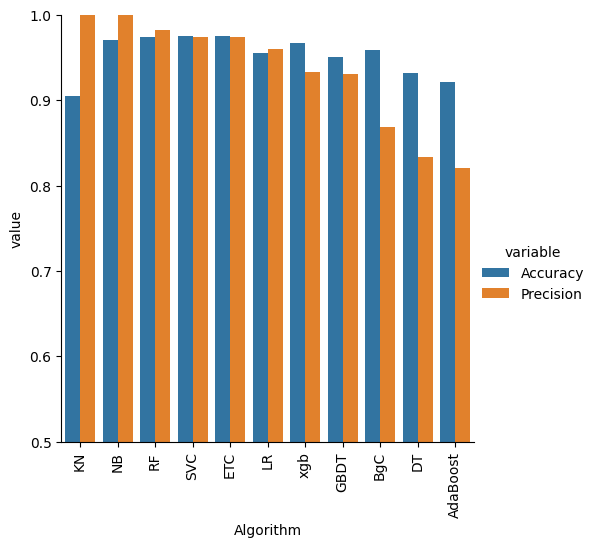

In [170]:
sns.catplot(x = 'Algorithm', y = 'value',
            hue = 'variable', data = performance_df1, kind = 'bar', height = 5)
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()


## model improve 
## 1.change the max_featres paramtere of Tfidf ( max feature is hidden feature of tfidf)

In [171]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(), 'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores }).sort_values('Precision_max_ft_3000', ascending=False)

In [172]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [173]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(), 'Accuracy_scaling':accuracy_scores, 'Precision_scaling':precision_scores})


In [174]:
new_df_scaled = new_df.merge(temp_df, on='Algorithm')


## Scaling se koi khaas frk ni pda o hm use include ni krnege but we ae tyring by adding num_chars column in X to see diff 

In [175]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(), 'Accuracy_num_chars':accuracy_scores, 'Precision_num_chars':precision_scores})
new_df_scaled.merge(temp_df, on='Algorithm')


,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_scaling,Precision_scaling,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RF,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609
3,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,LR,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000
6,xgb,0.967118,0.933333,0.967118,0.933333,0.967118,0.933333,0.967118,0.933333
7,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
8,BgC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
9,DT,0.932302,0.833333,0.932302,0.833333,0.932302,0.833333,0.932302,0.833333


## voting classifier -> combination of multiple model algos jo kbhi kbhi best performing algos se better form kr jta h yha hme improvemnt max_features updation k bad hi mila h 

In [176]:
# voting classifier
svc = SVC(kernel='sigmoid', gamma = 1.0, probability=True)
#mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [177]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb),('et', etc)], voting='soft')

In [178]:
voting.fit(X_train,y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [179]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9834710743801653


## Stacking is very similar to voting the only difference is voting May Jin models to combine Korea unknown equal weightage h in stacking Different weightage de rhe h by using final estimator

In [180]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb),('et', etc)]
final_estimator=RandomForestClassifier()

In [181]:
from sklearn.ensemble import StackingClassifier


In [182]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [183]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print('Accuracy',accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))


Accuracy 0.9796905222437138
Precision 0.9465648854961832


There is not very much difference between the output of the voting classifier or the stacking classifier That's why we've decided to use multinomial Navy bias because after applying so much improvement methods there wasn't so much difference an accuracy and precision So we'll create a pipeline to multinomial nave bays and then that pipeline to converting into website

In [184]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [185]:
# Test with a spam message
spam_msg = df[df['target']==1]['text'].iloc[0]
print("Spam message:", spam_msg)
transformed = transform_text(spam_msg)
print("Transformed:", transformed)
vector = tfidf.transform([transformed])
# Ensure mnb is fitted
#if not hasattr(mnb, 'classes_'):
    #mnb.fit(X_train, y_train)
print("Prediction:", mnb.predict(vector)[0])

Spam message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Transformed: free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18
Prediction: 1


In [186]:
spam_msg = df[df['target']==1]['text'].iloc[0]
transformed = transform_text(spam_msg)
vector = tfidf.transform([transformed])
print("Prediction:", mnb.predict(vector)[0])  # Should output 1 for spam

Prediction: 1
